# Anomaly
Anomaly" in machine learning refers to data points or patterns that deviate significantly from the norm or expected behavior.
 These anomalies are often referred to as outliers, novelties, or exceptions. Detecting and understanding anomalies is crucial in various applications.
 
 
Steps followed to find anomaly

1. Loaded dataset
2. verify dataset , perform EDA
3. picked up 2 variables 'sepal_length','sepal_width'
4. plot scatter plot for those variables
5. generated nearest neighbor model with 3 neighor value
6. verified for which indexes model identified as anomaly using plot graph for mean value
7. on basis of plot graph check minimum value after that values falls under anomaly
8. filter those values in array and generate scatter plot showing anomaly and rest of dataset

In [1]:
#import required libraries

import pandas as pd
import numpy as np

import matplotlib.pylab as plt

from sklearn.neighbors import NearestNeighbors

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
#use only 2 columns  sepal_length ,sepal_width

df= data[['sepal_length','sepal_width']]

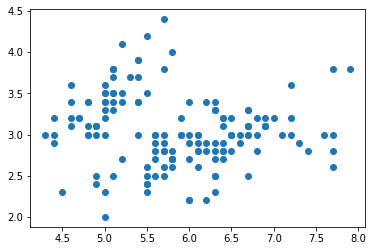

In [9]:

#plot scatter plot graph
plt.scatter(df['sepal_length'],df['sepal_width'])

In [12]:
#find out anomoly using KNN

X= df.values

nbrs =NearestNeighbors(n_neighbors=3)


nbrs.fit(X)

NearestNeighbors(n_neighbors=3)

In [14]:
nbrs.kneighbors(X)

(array([[0.        , 0.        , 0.1       ],
        [0.        , 0.1       , 0.1       ],
        [0.        , 0.        , 0.1       ],
        [0.        , 0.1       , 0.14142136],
        [0.        , 0.1       , 0.1       ],
        [0.        , 0.        , 0.2       ],
        [0.        , 0.2       , 0.2       ],
        [0.        , 0.        , 0.1       ],
        [0.        , 0.1       , 0.14142136],
        [0.        , 0.        , 0.        ],
        [0.        , 0.1       , 0.2       ],
        [0.        , 0.        , 0.2       ],
        [0.        , 0.        , 0.1       ],
        [0.        , 0.1       , 0.14142136],
        [0.        , 0.2236068 , 0.36055513],
        [0.        , 0.28284271, 0.41231056],
        [0.        , 0.        , 0.2       ],
        [0.        , 0.        , 0.1       ],
        [0.        , 0.2236068 , 0.31622777],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.14142136],
        [0.        , 0.1       , 0

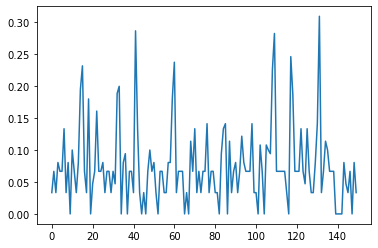

In [18]:
#identify which values are recongized as anomoly

distances, indexes= nbrs.kneighbors(X)

#with help of plot check what are outliers

plt.plot(distances.mean(axis=1))


In [21]:
#get indexes of anomolies , on basis of graph it is value >0.15

outliers_index= np.where(distances.mean(axis=1) >0.15)

outliers_index

(array([ 14,  15,  18,  22,  32,  33,  41,  59,  60, 108, 109, 117, 118,
        131], dtype=int64),)

In [26]:

#get values that are anomolies
outliers_values = df.iloc[outliers_index]
outliers_values

,sepal_length,sepal_width
14,5.8,4.0
15,5.7,4.4
18,5.7,3.8
22,4.6,3.6
32,5.2,4.1
33,5.5,4.2
41,4.5,2.3
59,5.2,2.7
60,5.0,2.0
108,6.7,2.5


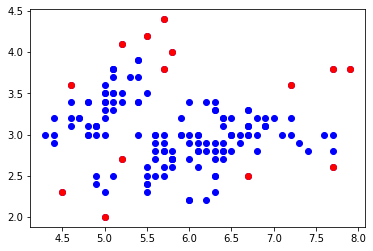

In [28]:
#create plot of anomolies and data

plt.scatter(df['sepal_length'],df['sepal_width'],c='blue' )

plt.scatter(outliers_values['sepal_length'],outliers_values['sepal_width'],c='red')